# Stock Return Prediction — Notebook Gabungan (EDA, Preprocessing & Modeling)

Notebook ini menggabungkan `Main_Notebook.ipynb` (EDA & eksplorasi awal) dan `modeling.ipynb` (feature engineering lanjutan + modeling) **menjadi satu alur kerja tanpa duplikasi**.

Perubahan utama dibanding dua notebook aslinya:
- Setiap tahap (load, missing values, feature engineering, scaling, dst.) sekarang **hanya dikerjakan satu kali**. Sebelumnya `Main_Notebook.ipynb` membangun ulang `train`/`test` beberapa kali (Bagian 4, 5, dan 7 saling tumpang tindih) — di sini hanya dipertahankan satu versi final, yaitu versi yang lebih matang (ada feature pruning, leak-free split, dan tidak perlu drop-lalu-rekonstruksi `Date`).
- Bagian yang murni eksplorasi/diagnostik (cek missing value, cardinality, autokorelasi return, dsb.) dipisahkan dengan jelas dari bagian yang benar-benar membentuk fitur final, dan tidak lagi menimpa variabel `train`/`test` yang dipakai pipeline.
- Scaling & outlier capping mengikuti pendekatan `modeling.ipynb` (fit **hanya di Train2**, bukan di seluruh train) supaya tidak ada kebocoran data ke validation/test — ini menggantikan scaling versi awal di `Main_Notebook.ipynb` yang fit di seluruh `train_final`.

Alur akhir: **Load & Split → Missing Values → EDA/Diagnostik → Feature Engineering → Feature Pruning → Finalisasi → EDA Fitur Final → Time-Aware Split (Train2/Val) → CV Folds → Outlier Capping → Scaling → Evaluasi → Modeling → Feature Importance → Hyperparameter Tuning → Perbandingan Model → Refit Final & Evaluasi Test.**


## 0. Import Library

In [1]:
!pip install pandas numpy scikit-learn scipy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import LinearSVR, SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.width", 120)


# 1. Load Dataset & Time-Series Split

## 1.1 Load Dataset Mentah

In [2]:
# Load data
df = pd.read_csv("EDA&Preprocessing/stock_prices.csv")

# Kolom yang akan dipertahankan
keep_cols = ["RowId", "Date", "SecuritiesCode", "Open", "High", "Low", "Close", "Volume", "Target"]
df = df[keep_cols].copy()

# Format kolom "Date" menjadi tipe datetime
df["Date"] = pd.to_datetime(df["Date"])

# Memastikan urutan data berdasarkan tanggal
df = df.sort_values("Date").reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")


Total rows: 2332531
Date range: 2017-01-04 → 2021-12-03


## 1.2 Time-Series Split

In [3]:
# Split berdasarkan tanggal, 80% untuk train dan 20% untuk test
split_date = df["Date"].quantile(0.8)

train = df[df["Date"] <= split_date].copy()
test  = df[df["Date"] >  split_date].copy()

print(f"\nTrain: {train['Date'].min().date()} → {train['Date'].max().date()}  ({len(train)} rows)")
print(f"Test : {test['Date'].min().date()} → {test['Date'].max().date()}  ({len(test)} rows)")

train.to_csv("train.csv", index=True)
test.to_csv("test.csv", index=True)

print(f"\nShape: {train.shape}")
print("\nDtypes:")
print(train.dtypes)



Train: 2017-01-04 → 2020-12-21  (1866532 rows)
Test : 2020-12-22 → 2021-12-03  (465999 rows)

Shape: (1866532, 9)

Dtypes:
RowId                        str
Date              datetime64[us]
SecuritiesCode             int64
Open                     float64
High                     float64
Low                      float64
Close                    float64
Volume                     int64
Target                   float64
dtype: object


# 2. Missing Values

## 2.1 Missing Values in Train & Test

In [4]:
missing = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_pct":   (train.isna().mean() * 100).round(4),
    "dtype":         train.dtypes.astype(str),
}).sort_values("missing_count", ascending=False)
print(missing)


                missing_count  missing_pct           dtype
High                     6503       0.3484         float64
Close                    6503       0.3484         float64
Open                     6503       0.3484         float64
Low                      6503       0.3484         float64
Target                    238       0.0128         float64
RowId                       0       0.0000             str
SecuritiesCode              0       0.0000           int64
Date                        0       0.0000  datetime64[us]
Volume                      0       0.0000           int64


In [5]:
missing_test = pd.DataFrame({
    "missing_count": test.isna().sum(),
    "missing_pct":   (test.isna().mean() * 100).round(4),
}).sort_values("missing_count", ascending=False)
print(missing_test)


                missing_count  missing_pct
High                     1105       0.2371
Close                    1105       0.2371
Open                     1105       0.2371
Low                      1105       0.2371
RowId                       0       0.0000
Date                        0       0.0000
SecuritiesCode              0       0.0000
Volume                      0       0.0000
Target                      0       0.0000


## 2.2 Ringkasan Missing Values di Train

In [6]:
total_cells           = train.shape[0] * train.shape[1]
total_missing         = train.isna().sum().sum()
rows_with_any_missing = train.isna().any(axis=1).sum()
rows_with_all_missing = train.isna().all(axis=1).sum()

print(f"Total cells           : {total_cells}")
print(f"Total missing cells   : {total_missing}  ({total_missing / total_cells * 100:.4f}%)")
print(f"Rows w/ >=1 missing   : {rows_with_any_missing}  ({rows_with_any_missing / len(train) * 100:.4f}%)")
print(f"Rows w/ ALL missing   : {rows_with_all_missing}")

for col in train.columns:
    if train[col].isna().any():
        idx = train.index[train[col].isna()]
        print(f"{col:16s} | first @row {idx.min():>7} | last @row {idx.max():>7} | n_missing={len(idx)}")
    else:
        print(f"{col:16s} | no missing values")


Total cells           : 16798788
Total missing cells   : 26250  (0.1563%)
Rows w/ >=1 missing   : 6503  (0.3484%)
Rows w/ ALL missing   : 0
RowId            | no missing values
Date             | no missing values
SecuritiesCode   | no missing values
Open             | first @row     664 | last @row 1866281 | n_missing=6503
High             | first @row     664 | last @row 1866281 | n_missing=6503
Low              | first @row     664 | last @row 1866281 | n_missing=6503
Close            | first @row     664 | last @row 1866281 | n_missing=6503
Volume           | no missing values
Target           | first @row    1141 | last @row 1758123 | n_missing=238


## 2.3 Missing Values by Year

In [7]:
train["_year"] = train["Date"].dt.year
print(train.groupby("_year").apply(lambda g: g.isna().sum()))
train.drop(columns="_year", inplace=True)


       RowId  Date  SecuritiesCode  Open  High   Low  Close  Volume  Target
_year                                                                      
2017       0     0               0  1131  1131  1131   1131       0     235
2018       0     0               0  1024  1024  1024   1024       0       1
2019       0     0               0  1217  1217  1217   1217       0       0
2020       0     0               0  3131  3131  3131   3131       0       2


## 2.4 Missing Values by Security

In [8]:
per_sec = train.groupby("SecuritiesCode").apply(lambda g: g.isna().sum())
per_sec = per_sec[per_sec.sum(axis=1) > 0]
if per_sec.empty:
    print("No security has any missing values.")
else:
    print(f"{per_sec.shape[0]} securities have missing values. Top 10:")
    print(per_sec.assign(total=per_sec.sum(axis=1))
                  .sort_values("total", ascending=False).head(10))


1991 securities have missing values. Top 10:
                RowId  Date  Open  High  Low  Close  Volume  Target  total
SecuritiesCode                                                            
3540                0     0   237   237  237    237       0     235   1183
9733                0     0   269   269  269    269       0       0   1076
2761                0     0   242   242  242    242       0       0    968
4365                0     0   234   234  234    234       0       0    936
1787                0     0   233   233  233    233       0       0    932
4628                0     0   217   217  217    217       0       0    868
1981                0     0   217   217  217    217       0       0    868
4781                0     0   210   210  210    210       0       0    840
5918                0     0   185   185  185    185       0       0    740
4621                0     0   181   181  181    181       0       0    724


## 2.5 Numeric Distribution & Skewness

In [9]:
num_cols = ["Open", "High", "Low", "Close", "Volume", "Target"]
print(train[num_cols].describe().T)
print("\nSkewness:")
print(train[num_cols].skew().round(4))


            count           mean           std        min           25%       50%            75%           max
Open    1860029.0    2527.140021  3.334071e+03  14.000000   1009.000000    1787.0    2991.000000  9.340000e+04
High    1860029.0    2558.340564  3.372449e+03  16.000000   1022.000000    1808.0    3025.000000  9.600000e+04
Low     1860029.0    2494.845134  3.294648e+03  13.000000    997.000000    1764.0    2953.500000  8.810000e+04
Close   1860029.0    2526.939581  3.333909e+03  15.000000   1009.000000    1787.0    2991.000000  9.360000e+04
Volume  1866532.0  712824.378902  4.159998e+06   0.000000  29600.000000  108700.0  412300.000000  6.436540e+08
Target  1866294.0       0.000408  2.375330e-02  -0.578541     -0.010436       0.0       0.010417  1.119512e+00

Skewness:
Open       8.6872
High       8.6658
Low        8.7009
Close      8.6835
Volume    35.4787
Target     0.7455
dtype: float64


# 3. Menangani Missing Values

## 3.1 Konfirmasi Pola Missing OHLC & Drop

In [10]:
ohlc_cols = ["Open", "High", "Low", "Close"]

for name, df_ in [("train", train), ("test", test)]:
    mask = df_[ohlc_cols].isna().any(axis=1)
    n = mask.sum()
    n_zero_vol = (df_.loc[mask, "Volume"] == 0).sum()
    print(f"{name}: OHLC-missing rows = {n}, of which Volume==0 = {n_zero_vol} "
          f"({n_zero_vol/n*100:.2f}%)" if n else f"{name}: no OHLC-missing rows")

drop_subset = ["Open", "High", "Low", "Close", "Target"]

train_clean = train.dropna(subset=drop_subset).reset_index(drop=True)
test_clean  = test.dropna(subset=drop_subset).reset_index(drop=True)

print(f"\nBefore: train={train.shape}  test={test.shape}")
print(f"After : train={train_clean.shape}  test={test_clean.shape}")
print(f"Dropped train rows: {len(train) - len(train_clean)} "
      f"({(len(train)-len(train_clean))/len(train)*100:.4f}%)")
print(f"Dropped test  rows: {len(test)  - len(test_clean)} "
      f"({(len(test)-len(test_clean))/len(test)*100:.4f}%)")


train: OHLC-missing rows = 6503, of which Volume==0 = 6503 (100.00%)
test: OHLC-missing rows = 1105, of which Volume==0 = 1105 (100.00%)

Before: train=(1866532, 9)  test=(465999, 9)
After : train=(1860029, 9)  test=(464894, 9)
Dropped train rows: 6503 (0.3484%)
Dropped test  rows: 1105 (0.2371%)


## 3.2 Verifikasi Setelah Cleanup

In [11]:
print("Remaining missing values — train:", int(train_clean.isna().sum().sum()))
print("Remaining missing values — test :", int(test_clean.isna().sum().sum()))

# Apakah ada saham yang hilang sepenuhnya?
before_secs = set(train["SecuritiesCode"].unique())
after_secs  = set(train_clean["SecuritiesCode"].unique())
lost = before_secs - after_secs
print(f"Securities present in train before: {len(before_secs)}  |  after: {len(after_secs)}")
if lost:
    print(f"  ⚠ {len(lost)} securities fully removed: {sorted(lost)[:20]}{'...' if len(lost) > 20 else ''}")
else:
    print("  ✓ No security was completely removed.")

print("\nVolume==0 rows remaining in train_clean:", int((train_clean["Volume"] == 0).sum()))
print("Volume==0 rows remaining in test_clean :", int((test_clean["Volume"]  == 0).sum()))

# Mulai dari sini train_clean/test_clean jadi satu-satunya sumber acuan untuk tahap selanjutnya
train, test = train_clean, test_clean


Remaining missing values — train: 0
Remaining missing values — test : 0
Securities present in train before: 1997  |  after: 1997
  ✓ No security was completely removed.

Volume==0 rows remaining in train_clean: 0
Volume==0 rows remaining in test_clean : 0


# 4. Diagnostik Data Bersih

Bagian ini murni eksplorasi (cardinality, validasi `RowId`/`SecuritiesCode`, distribusi target, dsb). Tidak ada pembentukan fitur di sini — `train`/`test` tetap dalam bentuk `train_clean`/`test_clean`, siap dipakai di Bagian 6 (Feature Engineering).

## 4.1 Tipe Data, Kardinalitas, dan Kolom Kategorikal

In [12]:
info = pd.DataFrame({
    "dtype":        train.dtypes.astype(str),
    "n_unique":     train.nunique(dropna=False),
    "n_rows":       len(train),
    "unique_ratio": (train.nunique(dropna=False) / len(train)).round(6),
})
print(info)

for col in train.columns:
    dt    = train[col].dtype
    n     = train[col].nunique(dropna=False)
    ratio = n / len(train)
    is_cat_dtype = str(dt) in ("object", "string", "str", "category")
    tag = []
    if is_cat_dtype:
        tag.append("dtype=categorical")
    if ratio > 0.95 and not str(dt).startswith("datetime"):
        tag.append("IDENTIFIER (nearly unique)")
    if 1 < n <= 50:
        tag.append("low-cardinality")
    print(f"{col:16s} | dtype={str(dt):15s} | nunique={n:>8} | ratio={ratio:.4f} | "
          f"{' , '.join(tag) if tag else '-'}")

obj_cols = train.select_dtypes(include=["object", "string", "str", "category"]).columns.tolist()
if not obj_cols:
    print("No object/string/category columns found.")
else:
    for col in obj_cols:
        print(f"\n--- {col} ---")
        print(f"dtype        : {train[col].dtype}")
        print(f"n_unique     : {train[col].nunique()}")
        print(f"top 5 values : {train[col].value_counts().head(5).to_dict()}")
        print(f"most common  : {train[col].mode().iloc[0] if not train[col].mode().empty else 'N/A'}")
        print(f"sample       : {train[col].dropna().unique()[:5]}")


                         dtype  n_unique   n_rows  unique_ratio
RowId                      str   1860029  1860029      1.000000
Date            datetime64[us]       968  1860029      0.000520
SecuritiesCode           int64      1997  1860029      0.001074
Open                   float64     21648  1860029      0.011639
High                   float64     22660  1860029      0.012183
Low                    float64     22610  1860029      0.012156
Close                  float64     22699  1860029      0.012204
Volume                   int64     81314  1860029      0.043717
Target                 float64    323943  1860029      0.174160
RowId            | dtype=str             | nunique= 1860029 | ratio=1.0000 | dtype=categorical , IDENTIFIER (nearly unique)
Date             | dtype=datetime64[us]  | nunique=     968 | ratio=0.0005 | -
SecuritiesCode   | dtype=int64           | nunique=    1997 | ratio=0.0011 | -
Open             | dtype=float64         | nunique=   21648 | ratio=0.0116 | -

## 4.2 Validasi RowId & SecuritiesCode

In [13]:
print(f"n_unique RowId       : {train['RowId'].nunique()}")
print(f"n_rows               : {len(train)}")
print(f"RowId fully unique?  : {train['RowId'].is_unique}")
print(f"sample RowIds        : {train['RowId'].head(3).tolist()}")
reconstructed = train["Date"].dt.strftime("%Y%m%d") + "_" + train["SecuritiesCode"].astype(str)
print(f"RowId == 'YYYYMMDD_Code'? : {(reconstructed == train['RowId']).mean():.4%} match")

all_codes = np.sort(train["SecuritiesCode"].unique())
gaps = np.diff(all_codes)
print(f"codes contiguous?            : {(gaps == 1).all()}")
print(f"largest gap between codes    : {int(gaps.max()) if len(gaps) else 0}")
rows_per_sec = train["SecuritiesCode"].value_counts()
print(f"rows per security: min={rows_per_sec.min()}, median={int(rows_per_sec.median())}, max={rows_per_sec.max()}")
print(f"securities with < 30 rows    : {int((rows_per_sec < 30).sum())}")

train_secs = set(train["SecuritiesCode"].unique())
test_secs  = set(test["SecuritiesCode"].unique())
print(f"Securities in train           : {len(train_secs)}")
print(f"Securities in test            : {len(test_secs)}")
print(f"In test but NOT in train      : {len(test_secs - train_secs)}")
if test_secs - train_secs:
    print(f"  examples: {sorted(test_secs - train_secs)[:10]}")
print(f"In train but NOT in test      : {len(train_secs - test_secs)}")


n_unique RowId       : 1860029
n_rows               : 1860029
RowId fully unique?  : True
sample RowIds        : ['20170104_1301', '20170104_7412', '20170104_7408']
RowId == 'YYYYMMDD_Code'? : 100.0000% match
codes contiguous?            : False
largest gap between codes    : 87
rows per security: min=1, median=968, max=968
securities with < 30 rows    : 6
Securities in train           : 1997
Securities in test            : 2000
In test but NOT in train      : 3
  examples: [np.int64(4168), np.int64(4169), np.int64(7342)]
In train but NOT in test      : 0


## 4.3 Rentang Tanggal, Distribusi Target, & Duplikasi

In [14]:
print(f"train Date range : {train['Date'].min().date()} -> {train['Date'].max().date()}")
print(f"test  Date range : {test['Date'].min().date()}  -> {test['Date'].max().date()}")
print(f"n unique dates   : train={train['Date'].nunique()}, test={test['Date'].nunique()}")
tmp = train.assign(_year=train["Date"].dt.year)
print("trading days per year:")
print(tmp.groupby("_year")["Date"].nunique())
del tmp

grp = train.groupby("SecuritiesCode")["Target"].agg(["mean", "std", "count"])
print(f"Overall Target mean/std          : {train['Target'].mean():.6f} / {train['Target'].std():.6f}")
print(f"Per-security Target mean std     : {grp['mean'].std():.6f}")
print(f"Per-security Target mean min/max : {grp['mean'].min():.6f} / {grp['mean'].max():.6f}")

dup = train.duplicated(subset=["Date", "SecuritiesCode"]).sum()
print(f"Duplicate (Date, SecuritiesCode) rows in train: {int(dup)}")

num_cols = ["Open", "High", "Low", "Close", "Volume", "Target"]
print(f"\nAll numeric? {all(pd.api.types.is_numeric_dtype(train[c]) for c in num_cols)}")
print(train[num_cols].dtypes)


train Date range : 2017-01-04 -> 2020-12-21
test  Date range : 2020-12-22  -> 2021-12-03
n unique dates   : train=968, test=233
trading days per year:
_year
2017    247
2018    245
2019    241
2020    235
Name: Date, dtype: int64
Overall Target mean/std          : 0.000385 / 0.023743
Per-security Target mean std     : 0.002221
Per-security Target mean min/max : -0.073276 / 0.042154
Duplicate (Date, SecuritiesCode) rows in train: 0

All numeric? True
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
Target    float64
dtype: object


# 5. Diagnostik Tambahan: Return, Volume, & Korelasi Awal

Diagnostik ini dulunya tersebar di beberapa "rebuild" `train`/`test` yang tumpang tindih di `Main_Notebook.ipynb`. Di sini dijalankan sekali saja, di atas salinan sementara (`diag`) supaya `train`/`test` asli tidak ikut berubah — fitur final tetap dibangun satu kali saja di Bagian 6.

In [15]:
def is_sorted_by(df, keys):
    if len(df) < 2:
        return True
    cols = []
    for k in keys:
        s = df[k]
        if pd.api.types.is_datetime64_any_dtype(s):
            cols.append(s.astype("int64").to_numpy())
        else:
            cols.append(s.to_numpy())
    arr = np.column_stack(cols).astype("int64")
    return bool((np.diff(arr, axis=0) >= 0).all())

diag = train.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True).copy()

print(f"train sorted by (Date, Code)? {is_sorted_by(diag, ['Date','SecuritiesCode'])}")
print(f"Duplicate (Date, Code) rows in train: "
      f"{int(diag.duplicated(['Date','SecuritiesCode']).sum())}")
per_sec_days = diag.groupby("SecuritiesCode")["Date"].nunique()
print(f"Days per security: min={per_sec_days.min()}, "
      f"median={int(per_sec_days.median())}, max={per_sec_days.max()}")


train sorted by (Date, Code)? False
Duplicate (Date, Code) rows in train: 0
Days per security: min=1, median=968, max=968


### Distribusi & Autokorelasi Return

In [16]:
diag["_ret"] = diag.groupby("SecuritiesCode")["Close"].pct_change()
print(diag["_ret"].describe(percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))
print(f"Extreme returns |r|>0.2 : {int((diag['_ret'].abs() > 0.2).sum())}")
print(f"Extreme returns |r|>0.5 : {int((diag['_ret'].abs() > 0.5).sum())}")

def lag1_autocorr(s):
    s = s.dropna()
    return s.autocorr(lag=1) if len(s) > 3 else np.nan

autocorrs = diag.groupby("SecuritiesCode")["_ret"].apply(lag1_autocorr).dropna()
print(f"\nMean lag-1 autocorr : {autocorrs.mean():.5f}")
print(f"Std  lag-1 autocorr : {autocorrs.std():.5f}")
print(f"% securities with |autocorr| > 0.05 : "
      f"{(autocorrs.abs() > 0.05).mean()*100:.2f}%")


count    1.858032e+06
mean     1.081933e-03
std      7.857862e-02
min     -9.004452e-01
0.1%    -1.299276e-01
1%      -6.313131e-02
5%      -3.389831e-02
50%      0.000000e+00
95%      3.569264e-02
99%      7.178608e-02
99.9%    1.664817e-01
max      2.009302e+01
Name: _ret, dtype: float64
Extreme returns |r|>0.2 : 1425
Extreme returns |r|>0.5 : 500

Mean lag-1 autocorr : 0.01079
Std  lag-1 autocorr : 0.05467
% securities with |autocorr| > 0.05 : 30.94%


### Distribusi Volume & Sebaran Cross-sectional

In [17]:
print(f"Volume skew (raw)   : {diag['Volume'].skew():.3f}")
print(f"Volume skew (log1p) : {np.log1p(diag['Volume']).skew():.3f}")
print(f"Volume == 0 count   : {int((diag['Volume'] == 0).sum())}")

daily_std = diag.groupby("Date")["_ret"].std()
print(f"\nDaily cross-sectional return std: mean={daily_std.mean():.5f}, "
      f"median={daily_std.median():.5f}, max={daily_std.max():.5f}")


Volume skew (raw)   : 35.421
Volume skew (log1p) : -0.125
Volume == 0 count   : 0

Daily cross-sectional return std: mean=0.02671, median=0.01942, max=1.81629


### Korelasi Kandidat Fitur dengan Target

In [18]:
diag["_hl"]       = (diag["High"] - diag["Low"]) / diag["Close"]
diag["_co"]       = (diag["Close"] - diag["Open"]) / diag["Open"]
diag["_logvol"]   = np.log1p(diag["Volume"])
diag["_ret_lag1"] = diag.groupby("SecuritiesCode")["_ret"].shift(1)

candidates = ["_hl", "_co", "_logvol", "_ret", "_ret_lag1", "month", "dayofweek", "quarter"] \
             if "month" in diag.columns else ["_hl", "_co", "_logvol", "_ret", "_ret_lag1"]
candidates = [c for c in candidates if c in diag.columns]
corr = diag[candidates + ["Target"]].corr()["Target"].drop("Target")
print(corr.sort_values(ascending=False).round(5))

del diag  # sekadar diagnostik, tidak dipakai lagi setelah ini


_hl          0.02044
_ret        -0.00038
_ret_lag1   -0.00296
_logvol     -0.00490
_co         -0.00756
Name: Target, dtype: float64


# 6. Feature Engineering

Fitur temporal, leak-free target encoding untuk `SecuritiesCode` (out-of-fold, fit hanya dari baris train), dan fitur return/volatilitas/cross-sectional rank. `train`+`test` digabung sementara supaya rolling/`pct_change` per saham tetap kontinu melewati batas train/test, lalu dipisah lagi setelahnya.

Catatan: ini adalah **satu-satunya** implementasi feature engineering di notebook ini (menggantikan tiga versi yang sebelumnya saling tumpang tindih di `Main_Notebook.ipynb` Bagian 4, 5, dan 7).

## 6.1 Fitur Temporal, Return, Volatilitas, & Rank

In [19]:
train["_split"] = "train"
test["_split"]  = "test"
full = pd.concat([train, test], axis=0, ignore_index=True)
full = full.sort_values(["SecuritiesCode", "Date"]).reset_index(drop=True)

# ---- Fitur temporal ----
full["year"]       = full["Date"].dt.year
full["month"]      = full["Date"].dt.month
full["day"]        = full["Date"].dt.day
full["dayofweek"]  = full["Date"].dt.dayofweek
full["quarter"]    = full["Date"].dt.quarter
full["dayofyear"]  = full["Date"].dt.dayofyear
full["weekofyear"] = full["Date"].dt.isocalendar().week.astype(int)

# ---- Return, bentuk intraday, volume, volatilitas, rank ----
g = full.groupby("SecuritiesCode", sort=False)
full["ret_1d"]  = g["Close"].pct_change()
full["ret_5d"]  = g["Close"].pct_change(5)
full["ret_20d"] = g["Close"].pct_change(20)

full["intraday_range"] = (full["High"] - full["Low"]) / full["Close"]
full["close_open"]     = (full["Close"] - full["Open"]) / full["Open"]
full["high_close"]     = (full["High"] - full["Close"]) / full["Close"]
full["low_close"]      = (full["Close"] - full["Low"]) / full["Close"]

full["log_volume"] = np.log1p(full["Volume"])
vol_ma20 = g["Volume"].transform(lambda s: s.rolling(20, min_periods=1).mean())
full["volume_ratio"] = full["Volume"] / vol_ma20

full["vol_5d"]  = g["ret_1d"].transform(lambda s: s.rolling(5,  min_periods=2).std())
full["vol_20d"] = g["ret_1d"].transform(lambda s: s.rolling(20, min_periods=5).std())

full["ret_rank"]    = full.groupby("Date")["ret_1d"].rank(pct=True)
full["volume_rank"] = full.groupby("Date")["Volume"].rank(pct=True)

print(f"Fitur ditambahkan. Shape full: {full.shape}")


Fitur ditambahkan. Shape full: (2324923, 30)


## 6.2 Leak-free Target Encoding untuk SecuritiesCode

In [20]:
K = 50
train_mask = full["_split"] == "train"
test_mask  = full["_split"] == "test"
global_mean = full.loc[train_mask, "Target"].mean()

full["SecuritiesCode_te"] = np.nan
tmp_train = full.loc[train_mask].sort_values("Date")

kf = KFold(n_splits=5, shuffle=False)
te_vals = pd.Series(index=tmp_train.index, dtype=float)
for tr_i, va_i in kf.split(tmp_train):
    sub = tmp_train.iloc[tr_i]
    agg = sub.groupby("SecuritiesCode")["Target"].agg(["mean", "count"])
    smoothed = (agg["count"] * agg["mean"] + K * global_mean) / (agg["count"] + K)
    va_rows = tmp_train.iloc[va_i]
    te_vals.loc[va_rows.index] = va_rows["SecuritiesCode"].map(smoothed).values

full.loc[te_vals.index, "SecuritiesCode_te"] = te_vals.fillna(global_mean).values

# Mapping penuh dari seluruh train -> diterapkan ke test (kode tak dikenal -> global mean)
agg_full = full.loc[train_mask].groupby("SecuritiesCode")["Target"].agg(["mean", "count"])
smoothed_full = (agg_full["count"] * agg_full["mean"] + K * global_mean) / (agg_full["count"] + K)
full.loc[test_mask, "SecuritiesCode_te"] = (
    full.loc[test_mask, "SecuritiesCode"].map(smoothed_full).fillna(global_mean)
)

print("Target encoding selesai. NaN tersisa:", int(full["SecuritiesCode_te"].isna().sum()))


Target encoding selesai. NaN tersisa: 0


# 7. Feature Pruning

Dua kelompok fitur dibuang, dengan alasan berbeda:

**A. Redundan (korelasi antar-fitur tinggi):**
- `dayofyear` & `weekofyear` — korelasi ~0.9998 satu sama lain, dan ~0.99 dengan `month`. Cukup simpan `month`, `dayofweek`, `quarter`.
- `volume_rank` — korelasi ~0.976 dengan `log_volume`.

**B. Noise/berisiko overfit (ditemukan dari diagnostik `feature_importances_` RandomForest pada eksperimen sebelumnya):**
- `day` (tanggal-dalam-bulan, 1-31) — muncul dengan importance ~40%, jauh melebihi semua fitur harga/return/volume gabungan (~8%). Tidak ada dasar teori keuangan yang mendukung pengaruh sebesar itu; nilai `day` yang granular (31 kemungkinan) memudahkan tree "menghafal" kombinasi tanggal spesifik di data training yang tidak generalize ke periode lain — pola klasik overfit-ke-noise.
- `year` — bermasalah secara struktural untuk time-series split: karena `validation`/`test` selalu berada di periode setelah `train2` (kronologis), nilai `year` di sana **selalu lebih besar** dari apa pun yang pernah dilihat model saat training. Tree-based model tidak bisa ekstrapolasi split numerik di luar rentang yang pernah diobservasi, jadi threshold yang dipelajari dari `year` praktis jadi konstan (tidak informatif) saat validasi/test.

Fitur di bawah **dibuang sebelum modeling**.

In [21]:
REDUNDANT_COLS = ["dayofyear", "weekofyear", "volume_rank"]
NOISE_PRONE_COLS = ["day", "year"]  # lihat justifikasi di sel markdown di atas

full = full.drop(columns=["Open", "High", "Low", "Close", "Volume"] + REDUNDANT_COLS + NOISE_PRONE_COLS)
print(f"Dibuang (raw OHLCV + redundan + noise-prone): "
      f"{['Open','High','Low','Close','Volume'] + REDUNDANT_COLS + NOISE_PRONE_COLS}")
print(f"Shape full setelah pruning: {full.shape}")


Dibuang (raw OHLCV + redundan + noise-prone): ['Open', 'High', 'Low', 'Close', 'Volume', 'dayofyear', 'weekofyear', 'volume_rank', 'day', 'year']
Shape full setelah pruning: (2324923, 21)


# 8. Finalisasi train_final / test_final

**Catatan desain:** kolom `Date` **sengaja dipertahankan** di `train_final`/`test_final` — dikeluarkan dari daftar fitur model (`FEATURE_COLS`), tapi tetap tersedia untuk time-aware split & cross-validation di bagian selanjutnya. Ini lebih simpel dan tidak perlu trik drop-lalu-rekonstruksi tanggal dari `year`/`month`/`day`.

In [22]:
train_final = full[full["_split"] == "train"].drop(columns="_split").reset_index(drop=True)
test_final  = full[full["_split"] == "test"].drop(columns="_split").reset_index(drop=True)

print(f"Sebelum drop NaN (akibat pct_change/rolling window): train={train_final.shape}  test={test_final.shape}")
train_final = train_final.dropna().reset_index(drop=True)
test_final  = test_final.dropna().reset_index(drop=True)
print(f"Setelah drop NaN: train={train_final.shape}  test={test_final.shape}")

train_final = train_final.drop(columns=["RowId", "SecuritiesCode"])
test_final  = test_final.drop(columns=["RowId", "SecuritiesCode"])

print(f"\nKolom final ({len(train_final.columns)}): {list(train_final.columns)}")
train_final.head()


Sebelum drop NaN (akibat pct_change/rolling window): train=(1860029, 20)  test=(464894, 20)
Setelah drop NaN: train=(1820193, 20)  test=(464730, 20)

Kolom final (18): ['Date', 'Target', 'month', 'dayofweek', 'quarter', 'ret_1d', 'ret_5d', 'ret_20d', 'intraday_range', 'close_open', 'high_close', 'low_close', 'log_volume', 'volume_ratio', 'vol_5d', 'vol_20d', 'ret_rank', 'SecuritiesCode_te']


,Date,Target,month,dayofweek,quarter,ret_1d,ret_5d,ret_20d,intraday_range,close_open,high_close,low_close,log_volume,volume_ratio,vol_5d,vol_20d,ret_rank,SecuritiesCode_te
0,2017-02-02,0.001838,2,3,1,-0.002194,-0.001464,-0.004741,0.004031,-0.002194,0.002565,0.001466,9.741027,0.945232,0.003804,0.004883,0.755245,-0.000191
1,2017-02-03,0.002202,2,4,1,-0.003298,-0.002567,-0.006574,0.004779,-0.000735,0.004779,0.000000,9.698982,0.910360,0.003971,0.004924,0.329925,-0.000191
2,2017-02-06,0.002197,2,0,1,0.001838,-0.003292,-0.005474,0.006239,-0.002927,0.003670,0.002569,9.787010,1.000000,0.003841,0.004943,0.495961,-0.000191
3,2017-02-07,0.000000,2,1,1,0.002202,0.003306,-0.006186,0.004394,0.002202,0.001831,0.002563,9.830971,1.061644,0.003336,0.004921,0.756611,-0.000191
4,2017-02-08,0.002923,2,2,1,0.002197,0.000731,-0.002914,0.004384,0.004035,0.000000,0.004384,9.711176,0.922819,0.002675,0.004948,0.430877,-0.000191


# 9. EDA Fitur Final: Distribusi, Outlier, & Korelasi

Visualisasi murni eksploratif di atas `train_final` — untuk melihat skewness/outlier sebelum diputuskan strategi capping. Capping yang benar-benar dipakai di pipeline (fit hanya di Train2, tanpa kebocoran) dikerjakan di Bagian 12.

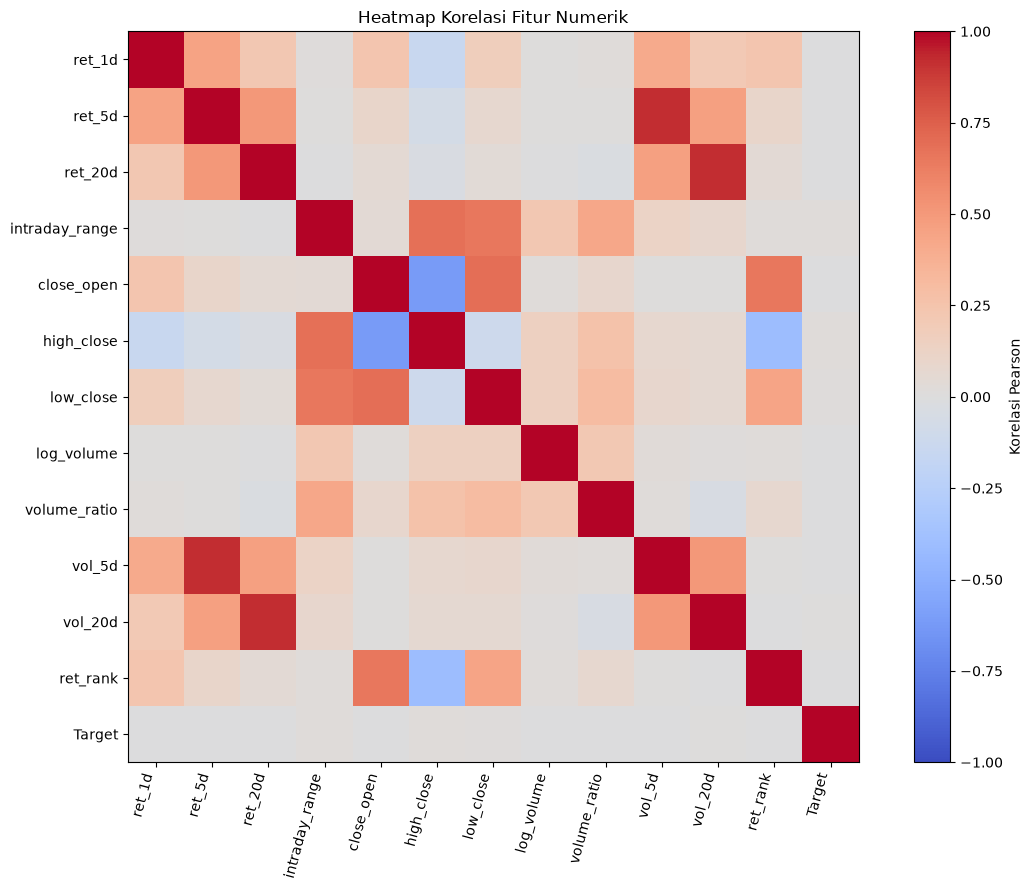

In [23]:
plot_sample = train_final.sample(n=min(50_000, len(train_final)), random_state=42)

heatmap_cols = [
    "ret_1d", "ret_5d", "ret_20d", "intraday_range", "close_open",
    "high_close", "low_close", "log_volume", "volume_ratio",
    "vol_5d", "vol_20d", "ret_rank", "Target",
]
heatmap_cols = [col for col in heatmap_cols if col in train_final.columns]
corr_matrix = train_final[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
image = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_cols)), heatmap_cols, rotation=75, ha="right")
ax.set_yticks(range(len(heatmap_cols)), heatmap_cols)
ax.set_title("Heatmap Korelasi Fitur Numerik")
fig.colorbar(image, ax=ax, label="Korelasi Pearson")
fig.tight_layout()
plt.show()


C:\Users\Nathanael\AppData\Local\Temp\ipykernel_14632\2122558639.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(plot_sample[col].dropna(), showfliers=True, vert=True)
C:\Users\Nathanael\AppData\Local\Temp\ipykernel_14632\2122558639.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(plot_sample[col].dropna(), showfliers=True, vert=True)
C:\Users\Nathanael\AppData\Local\Temp\ipykernel_14632\2122558639.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(plot_sample[col].dropna(), showfliers=True, vert=True)
C:\Users\Nathanael\AppData\Local\Temp\ipykernel_14632\2122558639.py:9: MatplotlibDeprecationWarning: vert: bool 

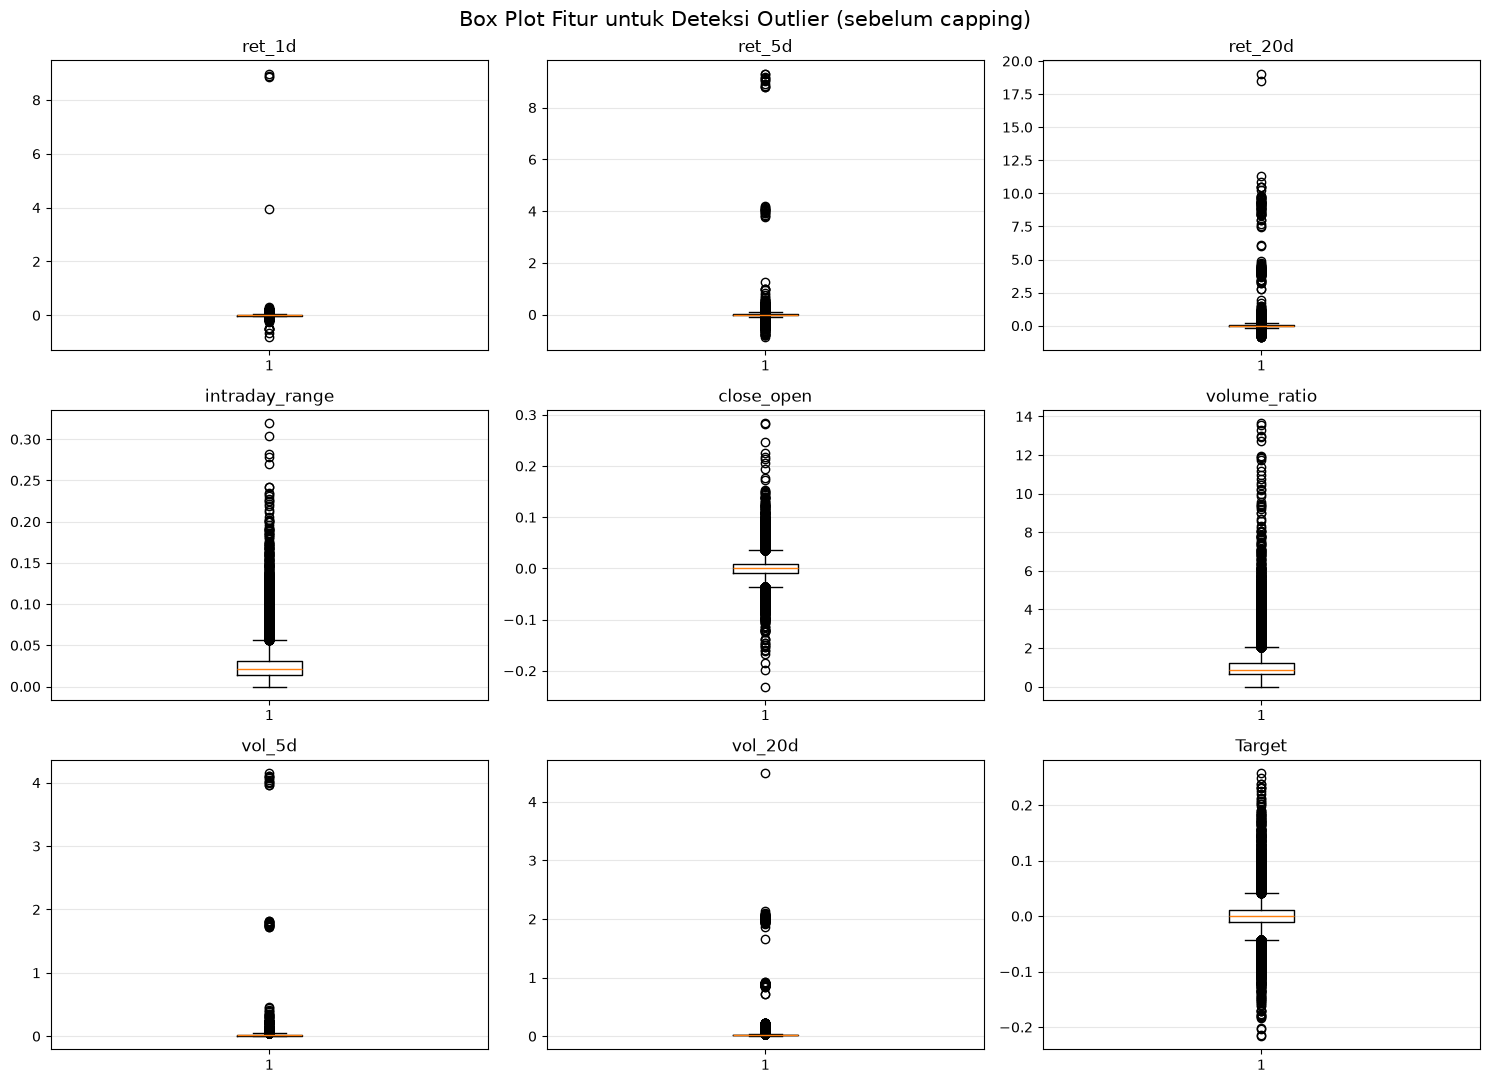

In [24]:
boxplot_cols = [
    "ret_1d", "ret_5d", "ret_20d", "intraday_range",
    "close_open", "volume_ratio", "vol_5d", "vol_20d", "Target",
]
boxplot_cols = [col for col in boxplot_cols if col in plot_sample.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, boxplot_cols):
    ax.boxplot(plot_sample[col].dropna(), showfliers=True, vert=True)
    ax.set_title(col)
    ax.grid(axis="y", alpha=0.3)
for ax in axes.flat[len(boxplot_cols):]:
    ax.set_visible(False)
fig.suptitle("Box Plot Fitur untuk Deteksi Outlier (sebelum capping)", fontsize=15)
fig.tight_layout()
plt.show()

del plot_sample


# 10. Time-Aware Split: Train -> Train2 / Validation

Split berbasis **ambang tanggal** (bukan index baris) — konsisten dengan pendekatan split di Bagian 1.2 — sekarang diterapkan di dalam `train_final` untuk menghasilkan `train2` (fit model) dan `validation` (evaluasi/model selection). `test_final` tetap disimpan sebagai held-out set, baru disentuh di Bagian 19.

In [25]:
def time_split_by_date(df: pd.DataFrame, date_col: str = "Date", val_frac: float = 0.15):
    dates_sorted = np.sort(df[date_col].unique())
    split_date = dates_sorted[int(len(dates_sorted) * (1 - val_frac))]
    tr_idx = df.index[df[date_col] <= split_date].to_numpy()
    va_idx = df.index[df[date_col] >  split_date].to_numpy()
    return tr_idx, va_idx

tr2_idx, val_idx = time_split_by_date(train_final, val_frac=0.15)
train2_final = train_final.loc[tr2_idx].reset_index(drop=True)
val_final    = train_final.loc[val_idx].reset_index(drop=True)

assert train2_final["Date"].max() < val_final["Date"].min(), "Leakage: overlap tanggal train2/validation!"

print(f"Train2      : {train2_final['Date'].min().date()} -> {train2_final['Date'].max().date()}  ({len(train2_final)} baris)")
print(f"Validation  : {val_final['Date'].min().date()} -> {val_final['Date'].max().date()}  ({len(val_final)} baris)")
print(f"Test (final): {test_final['Date'].min().date()} -> {test_final['Date'].max().date()}  ({len(test_final)} baris)")


Train2      : 2017-02-02 -> 2020-05-25  (1539702 baris)
Validation  : 2020-05-26 -> 2020-12-21  (280491 baris)
Test (final): 2020-12-22 -> 2021-12-03  (464730 baris)


# 11. Time-Series CV Folds (Expanding Window)

In [26]:
def make_expanding_time_folds(df: pd.DataFrame, date_col: str = "Date",
                               n_splits: int = 5, min_train_frac: float = 0.5):
    dates_sorted = np.sort(df[date_col].unique())
    n_dates = len(dates_sorted)
    start = int(n_dates * min_train_frac)
    fold_edges = np.linspace(start, n_dates - 1, n_splits + 1, dtype=int)
    folds = []
    for i in range(n_splits):
        cut, next_cut = dates_sorted[fold_edges[i]], dates_sorted[fold_edges[i + 1]]
        tr = df.index[df[date_col] <= cut].to_numpy()
        va = df.index[(df[date_col] > cut) & (df[date_col] <= next_cut)].to_numpy()
        if len(tr) and len(va):
            folds.append((tr, va))
    return folds

cv_folds = make_expanding_time_folds(train2_final, n_splits=5, min_train_frac=0.5)
print(f"Jumlah fold: {len(cv_folds)}\n")
for i, (tr, va) in enumerate(cv_folds):
    tr_end   = train2_final.loc[tr, "Date"].max().date()
    va_start = train2_final.loc[va, "Date"].min().date()
    va_end   = train2_final.loc[va, "Date"].max().date()
    print(f"Fold {i}: train={len(tr):>8,} (s.d. {tr_end})  |  val={len(va):>7,} ({va_start} -> {va_end})")


Jumlah fold: 5

Fold 0: train= 760,604 (s.d. 2018-09-19)  |  val=153,135 (2018-09-20 -> 2019-01-22)
Fold 1: train= 913,739 (s.d. 2019-01-22)  |  val=154,129 (2019-01-23 -> 2019-05-24)
Fold 2: train=1,067,868 (s.d. 2019-05-24)  |  val=156,841 (2019-05-27 -> 2019-09-19)
Fold 3: train=1,224,709 (s.d. 2019-09-19)  |  val=155,847 (2019-09-20 -> 2020-01-22)
Fold 4: train=1,380,556 (s.d. 2020-01-22)  |  val=159,146 (2020-01-23 -> 2020-05-25)


# 12. Data Transformation: Outlier Capping (fit di Train2 saja)

`ret_1d`, `ret_5d`, `ret_20d`, `vol_5d`, `vol_20d` sangat *skewed* (skewness bisa >100) karena beberapa outlier ekstrem. Ini terutama menyulitkan model linear/jarak (Ridge, SVR). Batas capping (IQR) di-*fit* **hanya dari `train2_final`**, baru diterapkan ke `validation` dan `test` — no leakage. Ini menggantikan demo capping di atas seluruh `train` yang sebelumnya ada di `Main_Notebook.ipynb`.

In [27]:
def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

CAP_COLS = ["ret_1d", "ret_5d", "ret_20d", "vol_5d", "vol_20d"]

print("Skewness SEBELUM capping (train2):")
print(train2_final[CAP_COLS].skew().round(3))

cap_bounds = {c: iqr_bounds(train2_final[c].dropna()) for c in CAP_COLS}

def apply_capping(df: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    df = df.copy()
    for c, (lo, hi) in bounds.items():
        df[c] = df[c].clip(lo, hi)
    return df

train2_final = apply_capping(train2_final, cap_bounds)
val_final    = apply_capping(val_final, cap_bounds)
test_final   = apply_capping(test_final, cap_bounds)

print("\nBatas capping (dari Train2):")
for c, (lo, hi) in cap_bounds.items():
    print(f"  {c:10s}: [{lo:.4f}, {hi:.4f}]")

print("\nSkewness SESUDAH capping (train2):")
print(train2_final[CAP_COLS].skew().round(3))


Skewness SEBELUM capping (train2):
ret_1d     91.844
ret_5d     41.083
ret_20d    21.109
vol_5d     44.507
vol_20d    22.597
dtype: float64

Batas capping (dari Train2):
  ret_1d    : [-0.0408, 0.0407]
  ret_5d    : [-0.0969, 0.0983]
  ret_20d   : [-0.2090, 0.2145]
  vol_5d    : [-0.0104, 0.0431]
  vol_20d   : [-0.0055, 0.0428]

Skewness SESUDAH capping (train2):
ret_1d     0.017
ret_5d     0.008
ret_20d    0.022
vol_5d     0.952
vol_20d    0.915
dtype: float64


# 13. Feature/Target Arrays & Scaling (fit di Train2 saja)

In [28]:
FEATURE_COLS = [c for c in train2_final.columns if c not in ("Target", "Date")]
TARGET_COL = "Target"

X_train2 = train2_final[FEATURE_COLS].values.astype(np.float64)
y_train2 = train2_final[TARGET_COL].values.astype(np.float64)
X_val    = val_final[FEATURE_COLS].values.astype(np.float64)
y_val    = val_final[TARGET_COL].values.astype(np.float64)
X_test   = test_final[FEATURE_COLS].values.astype(np.float64)
y_test   = test_final[TARGET_COL].values.astype(np.float64)

dates_val  = val_final["Date"].values
dates_test = test_final["Date"].values

# StandardScaler -- dipakai untuk Ridge & (Linear)SVR
scaler_X = StandardScaler().fit(X_train2)
X_train2_s = scaler_X.transform(X_train2)
X_val_s    = scaler_X.transform(X_val)
X_test_s   = scaler_X.transform(X_test)

print(f"Jumlah fitur: {len(FEATURE_COLS)}")
print(f"X_train2: {X_train2.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")


Jumlah fitur: 16
X_train2: (1539702, 16) | X_val: (280491, 16) | X_test: (464730, 16)


**Scaler cadangan (MinMaxScaler):** tetap disiapkan untuk kebutuhan pipeline berbasis jarak/neural-net di masa depan (mis. LSTM), fit dengan disiplin yang sama (hanya di Train2, tidak pernah menyentuh validation/test) — menggantikan versi awal di `Main_Notebook.ipynb` yang fit di seluruh `train_final` (berisiko bocor ke test).

In [29]:
scaler_X_minmax = MinMaxScaler().fit(X_train2)
X_train2_mm = scaler_X_minmax.transform(X_train2)
X_val_mm    = scaler_X_minmax.transform(X_val)
X_test_mm   = scaler_X_minmax.transform(X_test)

print("MinMaxScaler (fit di Train2 saja) siap dipakai bila diperlukan model berbasis jarak/neural-net.")


MinMaxScaler (fit di Train2 saja) siap dipakai bila diperlukan model berbasis jarak/neural-net.


# 14. Fungsi Evaluasi

In [30]:
def evaluate_regression(y_true, y_pred, dates=None, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    dir_acc = float(np.mean(np.sign(y_true) == np.sign(y_pred)))
    result = {"model": label, "RMSE": rmse, "MAE": mae, "R2": r2, "DirAcc": dir_acc}
    if dates is not None:
        tmp = pd.DataFrame({"date": dates, "y": y_true, "yhat": y_pred})
        daily_ic = tmp.groupby("date").apply(
            lambda g: spearmanr(g["y"], g["yhat"]).correlation if g["y"].nunique() > 2 else np.nan
        )
        result["MeanDailyIC"] = daily_ic.mean()
        result["ICWinRate"] = float((daily_ic > 0).mean())
    return result

eval_results = []


# 15. Model: Baseline, Ridge, HistGB, RandomForest, SVR

**Model yang dijalankan:** `DummyRegressor` (baseline), `Ridge`, `HistGradientBoostingRegressor`, `RandomForestRegressor`, `LinearSVR`, dan `SVR` (kernel RBF, subsample).

Alasan `RandomForestRegressor` ditambahkan sebagai pembanding: `HistGradientBoostingRegressor` (boosting) sudah ada — RandomForest (bagging) memberi pembanding metode ensemble yang beda karakter, cenderung lebih tahan overfitting di data noisy seperti return saham, walau biasanya sedikit kalah akurasi dibanding boosting yang di-tuning baik. RandomForest juga punya `feature_importances_` bawaan untuk mengecek ulang keputusan feature pruning di Bagian 7.

**Catatan performa:** `n_estimators`/`max_depth` di bawah nilai moderat. Kalau environment kamu banyak core (Colab/Kaggle), boleh dinaikkan (`n_estimators=300-500`) untuk hasil lebih stabil — RandomForest cukup mahal di CPU terbatas.

In [31]:
# --- Baseline ---
dummy = DummyRegressor(strategy="mean").fit(X_train2, y_train2)
eval_results.append(evaluate_regression(y_val, dummy.predict(X_val), dates_val, "Dummy (mean)"))

# --- Ridge ---
ridge = Ridge(alpha=1.0, random_state=42).fit(X_train2_s, y_train2)
eval_results.append(evaluate_regression(y_val, ridge.predict(X_val_s), dates_val, "Ridge"))


C:\Users\Nathanael\AppData\Local\Temp\ipykernel_14632\2842074386.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda g: spearmanr(g["y"], g["yhat"]).correlation if g["y"].nunique() > 2 else np.nan


In [32]:
# --- HistGradientBoosting ---
hgb = HistGradientBoostingRegressor(
    max_depth=6, learning_rate=0.05, max_iter=300,
    l2_regularization=1.0, early_stopping=True, validation_fraction=0.1, random_state=42,
).fit(X_train2, y_train2)
eval_results.append(evaluate_regression(y_val, hgb.predict(X_val), dates_val, "HistGradientBoosting"))


In [33]:
# --- RandomForest ---
# max_depth diturunkan & min_samples_leaf dinaikkan dibanding versi awal (8 / 20) --
# versi awal overfit ke noise (lihat diagnosis feature_importances_ & IC negatif di Bagian 16).
rf = RandomForestRegressor(
    n_estimators=200, max_depth=5, min_samples_leaf=100,
    max_features=0.5, n_jobs=-1, random_state=42,
).fit(X_train2, y_train2)
eval_results.append(evaluate_regression(y_val, rf.predict(X_val), dates_val, "RandomForest"))


In [34]:
# --- LinearSVR ---
linsvr = LinearSVR(C=1.0, epsilon=0.0, max_iter=10000, random_state=42).fit(X_train2_s, y_train2)
eval_results.append(evaluate_regression(y_val, linsvr.predict(X_val_s), dates_val, "LinearSVR"))

pd.DataFrame(eval_results).set_index("model").round(6)


c:\Users\Nathanael\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,RMSE,MAE,R2,DirAcc,MeanDailyIC,ICWinRate
model,,,,,,
Dummy (mean),0.025122,0.017194,-0.000244,0.472878,NaN,0.000000
Ridge,0.025104,0.017233,0.001149,0.481420,-0.018855,0.401408
HistGradientBoosting,0.025102,0.017220,0.001364,0.487577,0.009001,0.514085
RandomForest,0.025089,0.017198,0.002346,0.475801,0.002084,0.507042
LinearSVR,0.025143,0.017223,-0.001967,0.483199,-0.005548,0.485915


In [35]:
# --- SVR kernel RBF (subsample -- O(n^2)-O(n^3), tidak feasible full data) ---
# C diturunkan dari 1.0 -> 0.1 dibanding versi awal -- versi awal jelas overfit
# (R2 validation sampai -0.59), butuh regularisasi jauh lebih ketat untuk data se-noisy ini.
SVR_SUBSAMPLE_N = 20_000
rng = np.random.default_rng(42)
sub_idx = rng.choice(len(X_train2_s), size=min(SVR_SUBSAMPLE_N, len(X_train2_s)), replace=False)

svr = SVR(kernel="rbf", C=0.1, epsilon=0.01)
svr.fit(X_train2_s[sub_idx], y_train2[sub_idx])
eval_results.append(evaluate_regression(y_val, svr.predict(X_val_s), dates_val, f"SVR-RBF (subsample={len(sub_idx)})"))

pd.DataFrame(eval_results).set_index("model").round(6)


,RMSE,MAE,R2,DirAcc,MeanDailyIC,ICWinRate
model,,,,,,
Dummy (mean),0.025122,0.017194,-0.000244,0.472878,NaN,0.000000
Ridge,0.025104,0.017233,0.001149,0.481420,-0.018855,0.401408
HistGradientBoosting,0.025102,0.017220,0.001364,0.487577,0.009001,0.514085
RandomForest,0.025089,0.017198,0.002346,0.475801,0.002084,0.507042
LinearSVR,0.025143,0.017223,-0.001967,0.483199,-0.005548,0.485915
SVR-RBF (subsample=20000),0.026084,0.018086,-0.078308,0.491991,0.005837,0.570423


# 16. Feature Importance RandomForest (cek ulang Feature Pruning)

In [36]:
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("Feature importance (RandomForest):")
print(fi.round(4))
print("\nFitur dengan importance sangat rendah (<1% dari fitur teratas) -- kandidat dibuang lebih lanjut:")
print(fi[fi < fi.max() * 0.01])


Feature importance (RandomForest):
dayofweek            0.2112
month                0.1796
ret_5d               0.1325
ret_1d               0.1132
ret_20d              0.0895
quarter              0.0716
close_open           0.0490
intraday_range       0.0419
high_close           0.0257
vol_20d              0.0234
ret_rank             0.0185
low_close            0.0184
SecuritiesCode_te    0.0108
volume_ratio         0.0082
vol_5d               0.0062
log_volume           0.0003
dtype: float64

Fitur dengan importance sangat rendah (<1% dari fitur teratas) -- kandidat dibuang lebih lanjut:
log_volume    0.000274
dtype: float64


# 17. Hyperparameter Tuning dengan Time-Series CV

**Manual search loop, bukan `RandomizedSearchCV`.** Kandidat hyperparameter tetap disampel acak dengan `ParameterSampler` (setara `RandomizedSearchCV(..., n_iter=15, random_state=42)`), tapi tiap kandidat dievaluasi di tiap fold `cv_folds` (Bagian 11) memakai `evaluate_regression()` yang sama dari Bagian 14, lalu dipilih berdasarkan `MeanDailyIC` rata-rata antar fold tertinggi -- bukan `neg_root_mean_squared_error`. Ini menyamakan kriteria pemilihan hyperparameter dengan kriteria pemilihan model di Bagian 18 (lihat catatan di sana soal kenapa RMSE menyesatkan untuk return saham).

In [37]:
param_distributions = {
    "max_depth": [3, 4, 6, 8, None],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_iter": [100, 200, 300],
    "l2_regularization": [0.0, 0.5, 1.0, 2.0],
}

X_cv = train2_final[FEATURE_COLS].values.astype(np.float64)
y_cv = train2_final[TARGET_COL].values.astype(np.float64)
dates_cv = train2_final["Date"].values

# Sampling kandidat: setara RandomizedSearchCV(n_iter=15, random_state=42),
# supaya ruang pencarian & jumlah kandidat identik dengan versi RMSE sebelumnya --
# yang beda cuma kriteria evaluasinya.
param_candidates = list(ParameterSampler(param_distributions, n_iter=15, random_state=42))

search_results = []
for params in param_candidates:
    fold_ic = []
    for tr, va in cv_folds:
        model = HistGradientBoostingRegressor(random_state=42, **params)
        model.fit(X_cv[tr], y_cv[tr])
        pred = model.predict(X_cv[va])
        # evaluate_regression() sama persis dengan Bagian 14 -> MeanDailyIC per fold
        fold_metrics = evaluate_regression(y_cv[va], pred, dates_cv[va])
        fold_ic.append(fold_metrics["MeanDailyIC"])
    search_results.append({
        **params,
        "MeanFoldIC": float(np.nanmean(fold_ic)),
        "n_folds_valid": int(np.sum(~np.isnan(fold_ic))),
    })

search_results_df = (
    pd.DataFrame(search_results)
    .sort_values("MeanFoldIC", ascending=False)
    .reset_index(drop=True)
)
print(search_results_df.round(6))

best_row = search_results_df.iloc[0]
best_params = {k: best_row[k] for k in param_distributions}
# max_depth bisa None -> kolomnya jadi float (NaN utk None), kembalikan ke int/None asli
for k in ("max_depth", "max_iter"):
    best_params[k] = None if pd.isna(best_params[k]) else int(best_params[k])

print("\nBest params (MeanFoldIC tertinggi):", best_params)
print("Best MeanFoldIC (CV):", best_row["MeanFoldIC"])

best_hgb = HistGradientBoostingRegressor(random_state=42, **best_params).fit(X_cv, y_cv)
eval_results.append(evaluate_regression(y_val, best_hgb.predict(X_val), dates_val, "HistGB (tuned)"))

pd.DataFrame(eval_results).set_index("model").round(6)


    max_iter  max_depth  learning_rate  l2_regularization  MeanFoldIC  n_folds_valid
0        100        3.0           0.10                0.0    0.002012              5
1        300        6.0           0.10                0.5    0.000605              5
2        300        6.0           0.10                2.0   -0.000570              5
3        300        6.0           0.03                1.0   -0.000594              5
4        100        8.0           0.10                0.5   -0.000809              5
5        300        NaN           0.05                0.5   -0.001068              5
6        100        8.0           0.03                0.0   -0.001833              5
7        200        6.0           0.10                1.0   -0.002168              5
8        300        8.0           0.03                2.0   -0.002277              5
9        100        4.0           0.10                1.0   -0.002329              5
10       300        8.0           0.03                0.5   -0.00

,RMSE,MAE,R2,DirAcc,MeanDailyIC,ICWinRate
model,,,,,,
Dummy (mean),0.025122,0.017194,-0.000244,0.472878,NaN,0.000000
Ridge,0.025104,0.017233,0.001149,0.481420,-0.018855,0.401408
HistGradientBoosting,0.025102,0.017220,0.001364,0.487577,0.009001,0.514085
RandomForest,0.025089,0.017198,0.002346,0.475801,0.002084,0.507042
LinearSVR,0.025143,0.017223,-0.001967,0.483199,-0.005548,0.485915
SVR-RBF (subsample=20000),0.026084,0.018086,-0.078308,0.491991,0.005837,0.570423
HistGB (tuned),0.025049,0.017171,0.005544,0.507310,0.014120,0.556338


# 18. Perbandingan Model & Pemilihan Model Terbaik

**Kriteria pemilihan: `MeanDailyIC` tertinggi, bukan RMSE terendah.** Untuk return saham, RMSE/R2 didominasi noise yang memang tidak bisa diprediksi (bedanya antar model jadi kecil dan sering menyesatkan -- baseline `Dummy` bisa "menang" RMSE padahal tidak punya sinyal apa pun). `MeanDailyIC` (korelasi ranking harian) jauh lebih relevan: mengukur apakah model bisa mengurutkan saham dengan benar pada hari yang sama, yang itulah yang sebenarnya dipakai untuk keputusan (mis. ranking untuk trading), bukan ketepatan angka absolut.

`Dummy (mean)` otomatis tidak akan pernah menang di sini karena prediksinya konstan -> IC-nya `NaN` (tidak ada variasi untuk dihitung korelasinya).

In [38]:
results_df = pd.DataFrame(eval_results).set_index("model").round(6)
print(results_df)

best_model_name = results_df["MeanDailyIC"].idxmax()
print(f"\nModel terbaik (MeanDailyIC tertinggi) di validation: {best_model_name}")


                               RMSE       MAE        R2    DirAcc  MeanDailyIC  ICWinRate
model                                                                                    
Dummy (mean)               0.025122  0.017194 -0.000244  0.472878          NaN   0.000000
Ridge                      0.025104  0.017233  0.001149  0.481420    -0.018855   0.401408
HistGradientBoosting       0.025102  0.017220  0.001364  0.487577     0.009001   0.514085
RandomForest               0.025089  0.017198  0.002346  0.475801     0.002084   0.507042
LinearSVR                  0.025143  0.017223 -0.001967  0.483199    -0.005548   0.485915
SVR-RBF (subsample=20000)  0.026084  0.018086 -0.078308  0.491991     0.005837   0.570423
HistGB (tuned)             0.025049  0.017171  0.005544  0.507310     0.014120   0.556338

Model terbaik (MeanDailyIC tertinggi) di validation: HistGB (tuned)


# 19. Refit pada Seluruh Train & Evaluasi Final di Test

Model & hyperparameter terbaik (`best_params` dari Bagian 17) di-refit pada **seluruh `train_final`** (Train2 + Validation), lalu dievaluasi **sekali** di `test_final` (belum pernah disentuh selama tuning). Capping bounds di sini juga di-refit ulang dari `train_final` penuh, konsisten dengan disiplin "fit hanya di train" -- tapi sekarang train mencakup seluruh histori yang ada, bukan cuma Train2.

Jika `best_model_name` di Bagian 18 ternyata bukan `HistGB (tuned)`, ganti estimator di bawah sesuai model yang menang (mis. `RandomForestRegressor(...)` dengan hyperparameter dari Bagian 15).

In [39]:
# Refit capping bounds dari SELURUH train_final
cap_bounds_full = {c: iqr_bounds(train_final[c].dropna()) for c in CAP_COLS}
train_final_c = apply_capping(train_final, cap_bounds_full)
test_final_c  = apply_capping(test_final, cap_bounds_full)

X_train_full = train_final_c[FEATURE_COLS].values.astype(np.float64)
y_train_full = train_final_c[TARGET_COL].values.astype(np.float64)
X_test_full  = test_final_c[FEATURE_COLS].values.astype(np.float64)
y_test_full  = test_final_c[TARGET_COL].values.astype(np.float64)

# Ganti estimator di bawah sesuai `best_model_name` pada Bagian 18 (default: HistGB tuned)
final_model = HistGradientBoostingRegressor(**best_params, random_state=42)
final_model.fit(X_train_full, y_train_full)

pred_test = final_model.predict(X_test_full)
final_eval = evaluate_regression(y_test_full, pred_test, dates_test, label="FINAL (test set)")
print(final_eval)


{'model': 'FINAL (test set)', 'RMSE': np.float64(0.021987314887452914), 'MAE': 0.015166654649239315, 'R2': -0.00877589547253832, 'DirAcc': 0.4704279904460655, 'MeanDailyIC': np.float64(0.004630258719878921), 'ICWinRate': 0.4678111587982833}
